# Superstore Project 
Dataset containing Sales & Profits of a Superstore

-- Business Statistics & Insights | Master in Business Analytics & AI

The goal is to use the Superstore Sales dataset (9,994 transactions, 2014–2017) not just to complete the assignment, but to produce work that directly maps to the five skill areas in the target role. Each section below defines the analysis, the method, the business framing, and the free tool to use.

* Dataset: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final

### Task 3 - Statistical Inference

Methodology Notes: 

With n = 9,994 observations, almost every statistical test will return p < 0.05. A large sample makes it easy to detect tiny, practically meaningless differences. Throughout this analysis, statistical significance (p-value) is reported alongside effect size — the measure of how large the difference actually is. A finding is only business-relevant if it is both statistically significant and practically meaningful.

In [ ]:
# Load libraries and data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

df = pd.read_parquet('../data/processed/superstore_clean.parquet')
print(f"{df.shape[0]} rows loaded")

9994 rows loaded


#### 3.A — Confidence Intervals

A confidence interval answers: "What range of values is plausible for the true population mean?"

In [9]:
from scipy.stats import t

def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = data.mean()
    se = stats.sem(data)  # standard error
    margin = se * t.ppf((1 + confidence) / 2, df=n - 1)
    return mean, mean - margin, mean + margin

variables = {
    'Sales':         df['Sales'],
    'Profit':        df['Profit'],
    'Profit Margin': df['Profit Margin'],
    'Delivery Days': df['Delivery Days']
}

print(f"{'Variable':<20} {'Mean':>10} {'95% CI Lower':>14} {'95% CI Upper':>14}")
print("-" * 60)
for name, data in variables.items():
    mean, lo, hi = confidence_interval(data)
    print(f"{name:<20} {mean:>10.2f} {lo:>14.2f} {hi:>14.2f}")

Variable                   Mean   95% CI Lower   95% CI Upper
------------------------------------------------------------
Sales                    229.86         217.64         242.08
Profit                    28.66          24.06          33.25
Profit Margin              0.12           0.11           0.13
Delivery Days              3.96           3.92           3.99


Visualize them

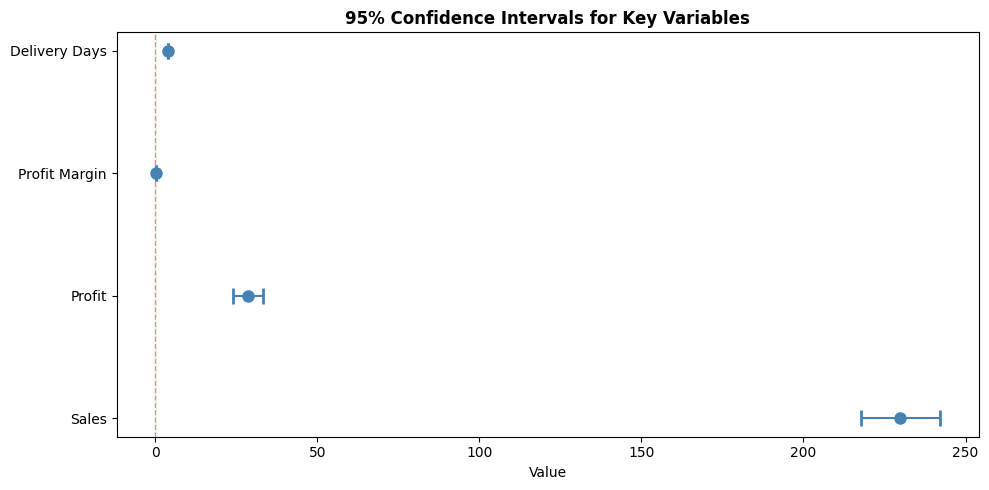

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

results = []
for name, data in variables.items():
    mean, lo, hi = confidence_interval(data)
    results.append({'Variable': name, 'Mean': mean, 'Lower': lo, 'Upper': hi})

ci_df = pd.DataFrame(results)

for i, row in ci_df.iterrows():
    ax.errorbar(row['Mean'], row['Variable'],
                xerr=[[row['Mean'] - row['Lower']], [row['Upper'] - row['Mean']]],
                fmt='o', color='steelblue', capsize=6, capthick=2, markersize=8)

ax.axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.set_title('95% Confidence Intervals for Key Variables', fontweight='bold')
ax.set_xlabel('Value')
plt.tight_layout()
plt.savefig('../output/images/03_confidence_intervals.png', dpi=150, bbox_inches='tight')
plt.show()

With 95% confidence, the true mean sales per transaction lies between $218 and $242. Despite the substantial variability observed in individual transactions, the large sample size (n = 9,994) results in relatively narrow confidence intervals by reducing the standard error of the mean. The 95% confidence interval for Profit Margin ranges from 11% to 13% and remains entirely positive, indicating that the average transaction is profitable and providing strong evidence of overall profitability at the aggregate business level. Nevertheless, the presence of loss-making transactions elsewhere in the distribution suggests that profitability is not uniform across all orders, products, or customer segments.

#### 3.B. Comparison of Means

In [14]:
from scipy.stats import normaltest

for col in ['Sales', 'Profit', 'Delivery Days']:
    stat, p = normaltest(df[col])
    print(f"{col}: p = {p:.4f} - {'NOT normal' if p < 0.05 else 'Normal'}")

Sales: p = 0.0000 - NOT normal
Profit: p = 0.0000 - NOT normal
Delivery Days: p = 0.0000 - NOT normal


* Sales → strongly right-skewed
* Profit → right-skewed with heavy tails
* Delivery Days → discrete and likely skewed

Although Sales, Profit, and Delivery Days are not normally distributed according to D'Agostino and Pearson's normality test (p < 0.001), the large sample size (n = 9,994) allows the Central Limit Theorem to apply. Consequently, the sampling distribution of the mean is approximately normal, making the reported 95% confidence intervals reliable despite the strong skewness and heavy tails present in the underlying data.

Comparison 1: Does profit differ between West and Central regions?

The Mann-Whitney U test (also known as the Wilcoxon rank-sum test) is a non-parametric statistical test used to determine whether there is a statistically significant difference between two independent groups. 
* It is the non-parametric equivalent of the independent t-test. When to Use It? 
    * You should use this test over an independent t-test when your data violates the assumptions of parametric tests, meaning: 
    * Non-normally distributed data: Your dependent variable is heavily skewed or does not follow a bell curve.
    * Ordinal data: The data consists of ranks or ratings (e.g., pain scale 1-10) rather than continuous measurements.
    * Outliers: Your data contains extreme outliers that would skew the mean.
    * Small sample sizes: You have limited data, usually less than 30 participants per group.

In [16]:
from scipy.stats import mannwhitneyu

west    = df[df['Region'] == 'West']['Profit']
central = df[df['Region'] == 'Central']['Profit']

stat, p = mannwhitneyu(west, central, alternative='two-sided')

# Effect size: rank-biserial correlation
n1, n2 = len(west), len(central)
r = 1 - (2 * stat) / (n1 * n2)

print(f"West median profit:    ${west.median():.2f}")
print(f"Central median profit: ${central.median():.2f}")
print(f"Mann-Whitney U: {stat:.0f}")
print(f"p-value: {p:.4f}")
print(f"Effect size (r): {r:.3f}  {'small' if abs(r)<0.3 else 'medium' if abs(r)<0.5 else 'large'}")

West median profit:    $11.17
Central median profit: $5.18
Mann-Whitney U: 4590569
p-value: 0.0000
Effect size (r): -0.234  small


The West region exhibits significantly higher profit per transaction than the Central region (median profit: $11.17 vs. $5.18). A Mann-Whitney U test confirmed that the difference in profit distributions is statistically significant (p < 0.001). However, the effect size is small (|r| = 0.234), indicating that although the difference is consistent across many transactions, the magnitude of the advantage is modest. Consequently, regional location appears to influence profitability, but it is unlikely to be the primary driver of profit variation compared with factors such as product category, discounting, or customer segment.

Comparison 2 - Does sales differ between Consumer and Corporate Segments?

In [17]:
consumer  = df[df['Segment'] == 'Consumer']['Sales']
corporate = df[df['Segment'] == 'Corporate']['Sales']

stat, p = mannwhitneyu(consumer, corporate, alternative='two-sided')
r = 1 - (2 * stat) / (len(consumer) * len(corporate))

print(f"Consumer median sales:  ${consumer.median():.2f}")
print(f"Corporate median sales: ${corporate.median():.2f}")
print(f"p-value: {p:.4f}")
print(f"Effect size (r): {r:.3f}  {'small' if abs(r)<0.3 else 'medium' if abs(r)<0.5 else 'large'}")

Consumer median sales:  $53.72
Corporate median sales: $56.54
p-value: 0.4712
Effect size (r): 0.010  small


A Mann-Whitney U test was conducted to compare sales between Consumer and Corporate customers. The test found no statistically significant difference between the two segments (p = 0.471). Median sales were similar for Consumer ($53.72) and Corporate ($56.54) customers. The effect size was negligible (r = 0.010), indicating that customer segment has little influence on transaction-level sales. Therefore, there is insufficient evidence to conclude that sales behavior differs meaningfully between Consumer and Corporate customers.

Comparison 3 - Does delivery time differ by Ship Mode?

In [18]:
ship_modes = df['Ship Mode'].unique()
print("Median delivery days by ship mode:")
print(df.groupby('Ship Mode')['Delivery Days'].median().sort_values())

# Test the two extremes
same_day  = df[df['Ship Mode'] == 'Same Day']['Delivery Days']
standard  = df[df['Ship Mode'] == 'Standard Class']['Delivery Days']

stat, p = mannwhitneyu(same_day, standard, alternative='two-sided')
r = 1 - (2 * stat) / (len(same_day) * len(standard))

print(f"\nSame Day vs Standard Class:")
print(f"p-value: {p:.4f}")
print(f"Effect size (r): {r:.3f}")

Median delivery days by ship mode:
Ship Mode
Same Day          0.0
First Class       2.0
Second Class      3.0
Standard Class    5.0
Name: Delivery Days, dtype: float64

Same Day vs Standard Class:
p-value: 0.0000
Effect size (r): 1.000


Delivery performance differs substantially across shipping modes. Same Day shipments have a median delivery time of 0 days, compared with 5 days for Standard Class shipments. A Mann-Whitney U test confirmed that this difference is highly significant (p < 0.001), while the rank-biserial correlation reached its maximum value (r = 1.000), indicating complete practical separation between the two distributions. This result confirms that shipping mode is the primary determinant of delivery speed and that the service levels offered by the company are clearly differentiated in operational performance.

#### 3.C. ANOVA

A standard ANOVA (Analysis of Variance) assumes thr data is "normally distributed" (a bell curve). However, financial data—especially Profit—is rarely "normal." It is usually skewed by extreme outliers (very large wins or very large losses).
* ANOVA tests whether means differ across more than two groups simultaneously. Use it for Region (4 groups) and Segment (3 groups).
* Since the data isn't normal, we will use Kruskal-Wallis (non-parametric ANOVA)

* ANOVA (Parametric): Compares the means (averages). It fails if the data is skewed.
* Kruskal-Wallis (Non-Parametric): Compares the ranks (medians). It is the "safe" version of ANOVA that doesn't care if your data is messy or skewed.

In [19]:
from scipy.stats import kruskal
from itertools import combinations

# ANOVA 1: Profit across all 4 Regions
groups_region = [df[df['Region'] == r]['Profit'].values for r in df['Region'].unique()]
stat, p = kruskal(*groups_region)
print(f"Kruskal-Wallis — Profit by Region")
print(f"H-statistic: {stat:.2f}, p-value: {p:.4f}")
print(f"Conclusion: {'Significant difference exists' if p < 0.05 else 'No significant difference'}\n")

# ANOVA 2: Sales across all 3 Segments
groups_segment = [df[df['Segment'] == s]['Sales'].values for s in df['Segment'].unique()]
stat, p = kruskal(*groups_segment)
print(f"Kruskal-Wallis — Sales by Segment")
print(f"H-statistic: {stat:.2f}, p-value: {p:.4f}")
print(f"Conclusion: {'Significant difference exists' if p < 0.05 else 'No significant difference'}")

Kruskal-Wallis — Profit by Region
H-statistic: 227.90, p-value: 0.0000
Conclusion: Significant difference exists

Kruskal-Wallis — Sales by Segment
H-statistic: 0.68, p-value: 0.7103
Conclusion: No significant difference


In [21]:
from scipy.stats import mannwhitneyu

print("\nPost-hoc pairwise tests — Profit by Region (Bonferroni corrected):")
regions = df['Region'].unique()
pairs = list(combinations(regions, 2))
alpha_corrected = 0.05 / len(pairs)  # Bonferroni correction

for r1, r2 in pairs:
    g1 = df[df['Region'] == r1]['Profit']
    g2 = df[df['Region'] == r2]['Profit']
    stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
    sig = '✓ SIGNIFICANT' if p < alpha_corrected else '✗ not significant'
    print(f"  {r1} vs {r2}: p={p:.4f} {sig}")

print(f"\n(Bonferroni corrected α = {alpha_corrected:.4f})")


Post-hoc pairwise tests — Profit by Region (Bonferroni corrected):
  South vs West: p=0.0002 ✓ SIGNIFICANT
  South vs Central: p=0.0000 ✓ SIGNIFICANT
  South vs East: p=0.0185 ✗ not significant
  West vs Central: p=0.0000 ✓ SIGNIFICANT
  West vs East: p=0.0000 ✓ SIGNIFICANT
  Central vs East: p=0.0000 ✓ SIGNIFICANT

(Bonferroni corrected α = 0.0083)


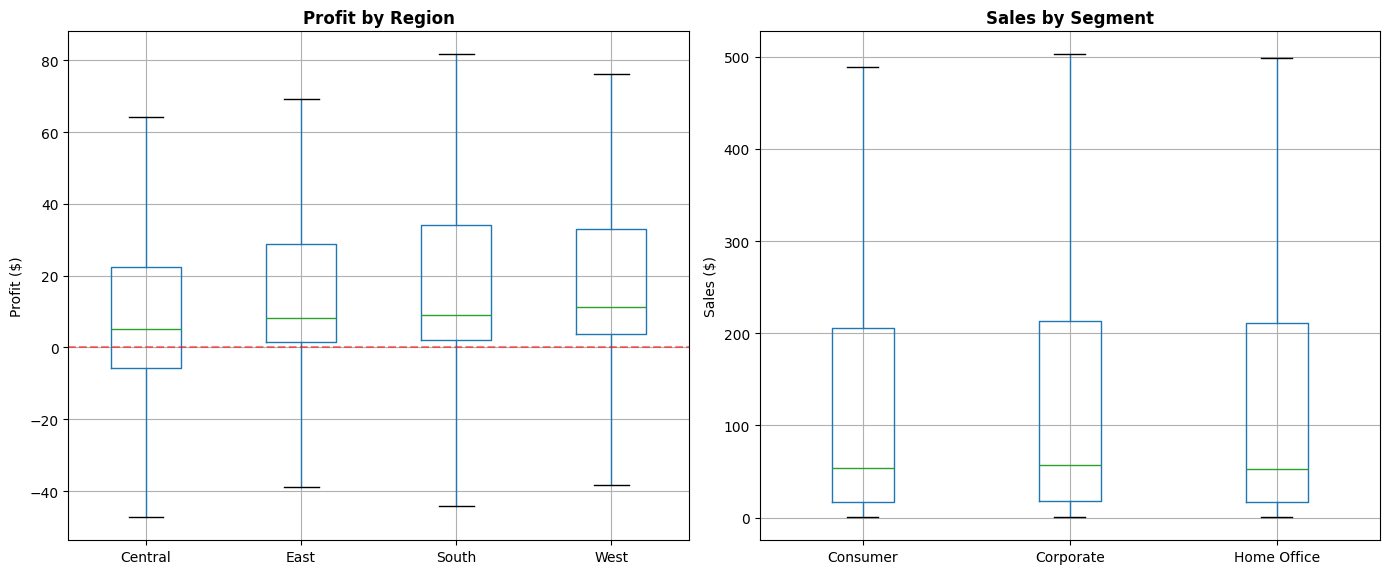

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Profit by Region
df.boxplot(column='Profit', by='Region', ax=axes[0],
           showfliers=False)  # hide outliers for readability
axes[0].set_title('Profit by Region', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Profit ($)')
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)

# Sales by Segment
df.boxplot(column='Sales', by='Segment', ax=axes[1], showfliers=False)
axes[1].set_title('Sales by Segment', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Sales ($)')

plt.suptitle('')
plt.tight_layout()
plt.savefig('../output/images/03_anova_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

The Kruskal-Wallis test reveals a statistically significant difference in profit across the four regions (H = 227.90, p < 0.001). Post-hoc pairwise tests with Bonferroni correction (adjusted α = 0.0083) identify 5 out of 6 region pairs as significant sources of this difference: West vs Central, West vs East, Central vs East, South vs West, and South vs Central all show significant differences in profit. The only non-significant pair is South vs East (p = 0.0185), suggesting these two regions have comparable profit distributions. The West region is the standout performer, differing significantly from all other regions, while Central is the weakest, also differing significantly from all others. However, as noted in the pairwise comparison (effect size r = 0.234, small), the practical magnitude of these differences is modest — the statistical significance is partly driven by the large sample size (n = 9,994), and findings should be interpreted with that context in mind.